In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

image_data_list = []
for i in range(1, 6):
    filename = f"M13_{i:04d}.fits"
    with fits.open(filename) as hdul:
        data = hdul[0].data
        image_data_list.append(data)
        print(f"Loaded {filename} with shape: {data.shape}")


Loaded M13_0001.fits with shape: (1040, 1392)
Loaded M13_0002.fits with shape: (1040, 1392)
Loaded M13_0003.fits with shape: (1040, 1392)
Loaded M13_0004.fits with shape: (1040, 1392)
Loaded M13_0005.fits with shape: (1040, 1392)

Successfully loaded 5 images.


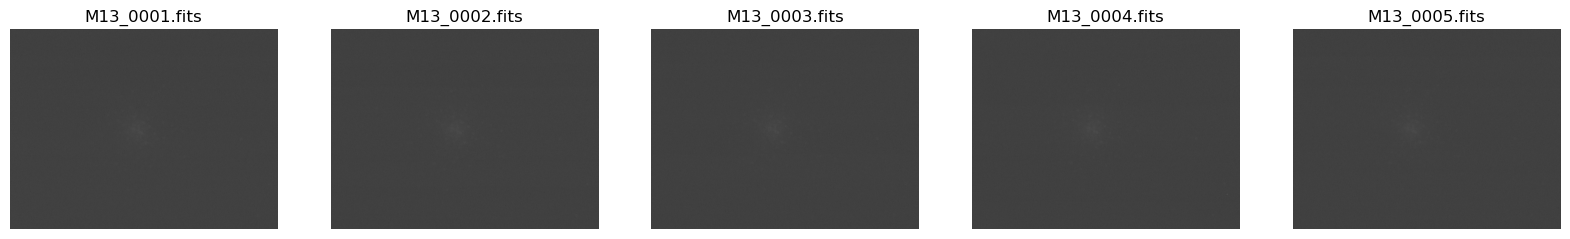

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, ax in enumerate(axes):
    if i < len(image_data_list):
        im = ax.imshow(image_data_list[i], origin='lower', cmap='gray', vmin=0, vmax=2000)
        
        ax.set_title(f"M13_{i+1:04d}.fits")
        ax.axis('off') 
plt.show()

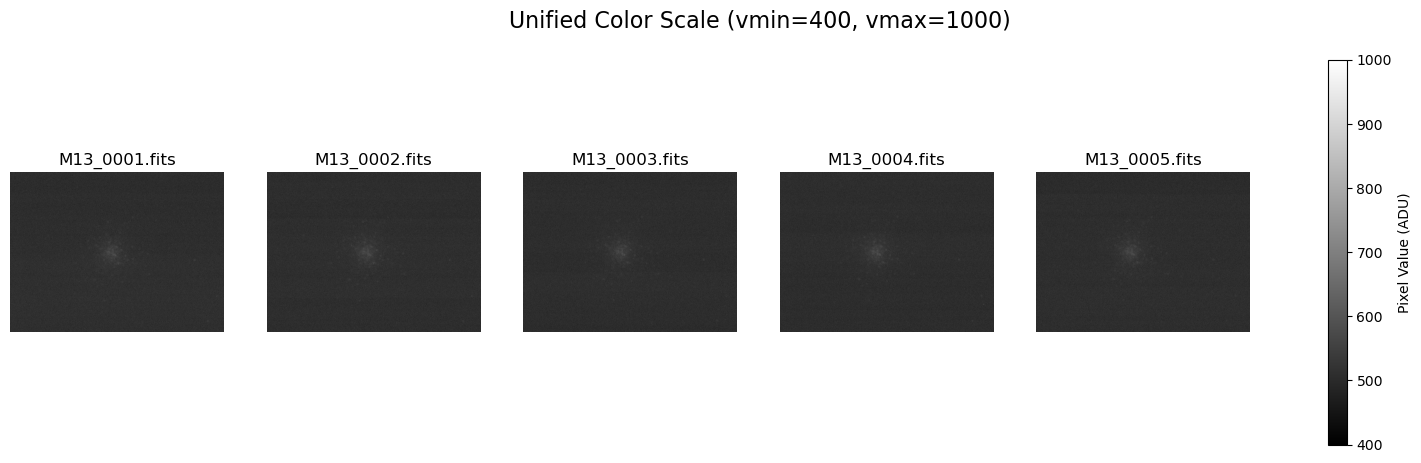

In [4]:
vmin_val = 400 
vmax_val = 1000 
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
images = []
for i, ax in enumerate(axes):
    if i < len(image_data_list):
        im = ax.imshow(image_data_list[i], origin='lower', cmap='gray', vmin=vmin_val, vmax=vmax_val)
        ax.set_title(f"M13_{i+1:04d}.fits")
        ax.axis('off')
        images.append(im)
fig.colorbar(images[0], ax=axes.ravel().tolist(), label='Pixel Value (ADU)')
plt.suptitle(f"Unified Color Scale (vmin={vmin_val}, vmax={vmax_val})", fontsize=16)
plt.show()

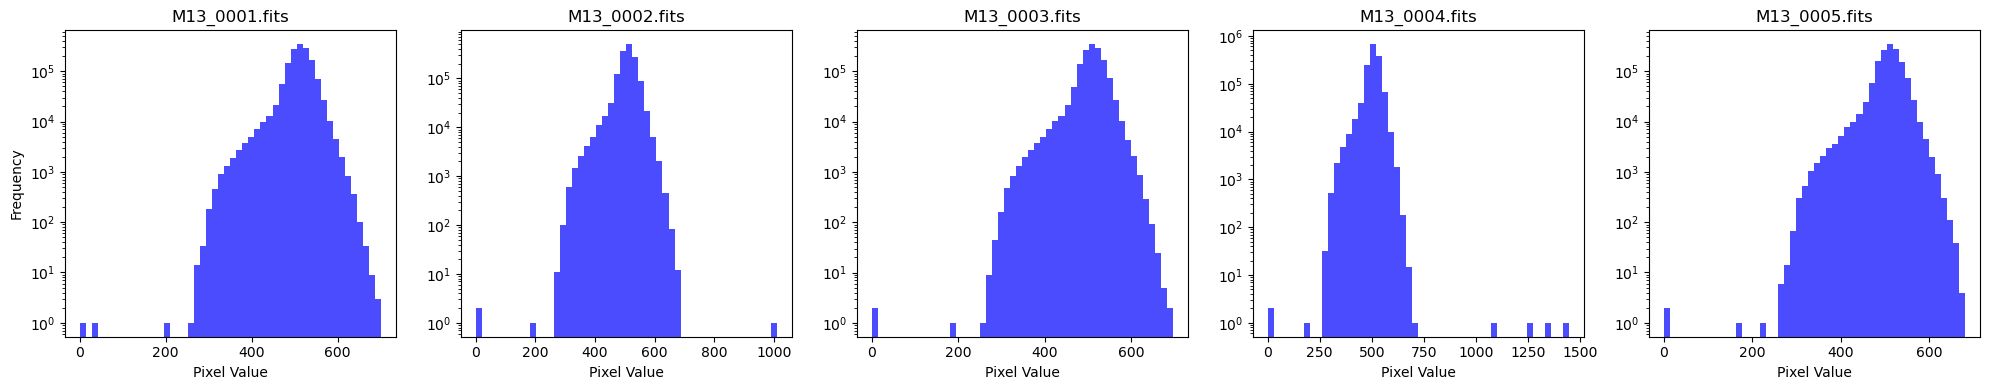

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ax in enumerate(axes):
    filename = f"M13_{i+1:04d}.fits"
    with fits.open(filename) as hdul:
        data = hdul[0].data
        ax.hist(data.ravel(), bins=50, color='blue', alpha=0.7)
        ax.set_title(filename)
        ax.set_xlabel("Pixel Value")
        if i == 0:
            ax.set_ylabel("Frequency")
        ax.set_yscale('log') #I used log to make it easier to see
plt.tight_layout()
plt.show()
#Used google to help find formatting

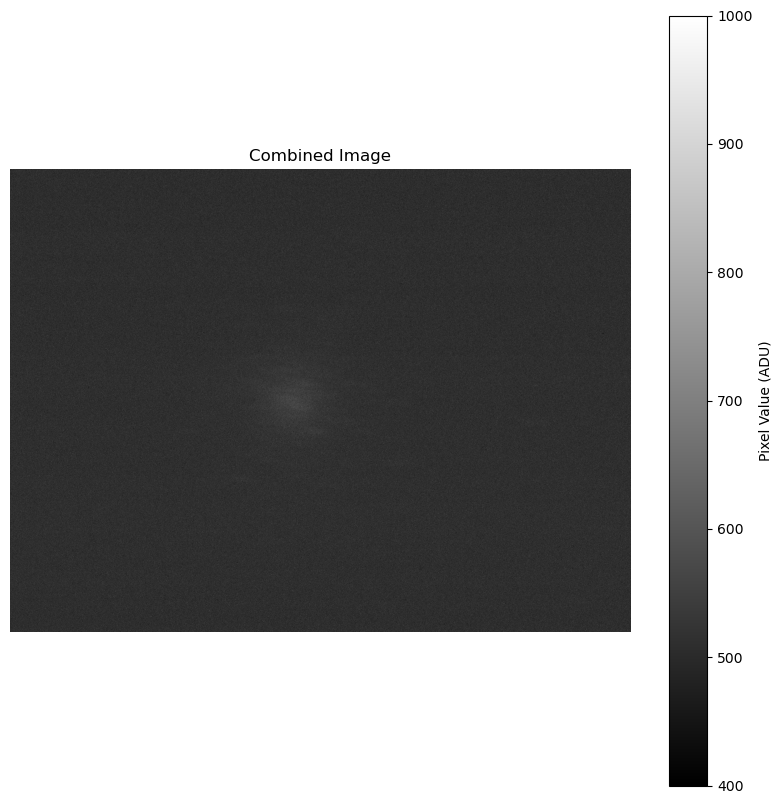

In [10]:
#X axis is pixel intensity value and y axis is log frequency
#The bins allows you to see the shape. More bins for the combined one bewlow. 
#data is centered around400 to 600
#Data is relativley close together
#median/mean is around 500 frr each. 
image_stack = np.array(image_data_list)
median_image = np.median(image_stack, axis=0)
plt.figure(figsize=(10, 10))
plt.imshow(median_image, origin='lower', cmap='gray', vmin=400, vmax=1000)
plt.title("Combined Image")
plt.colorbar(label='Pixel Value (ADU)')
plt.axis('off')
plt.show()

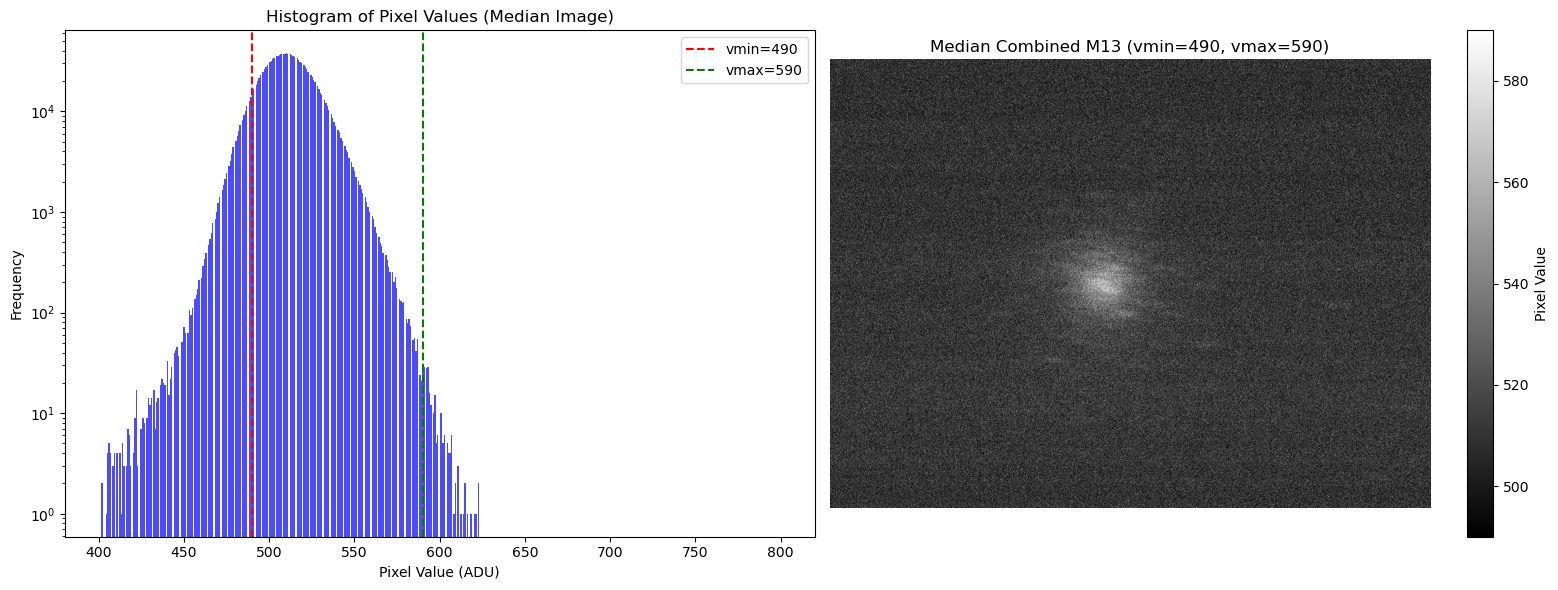

In [13]:
#New avg pixel intensity around 700
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
flat_data = median_image.ravel()
ax1.hist(flat_data, bins=500, range=(400, 800), color='blue', alpha=0.7)
ax1.set_title("Histogram of Pixel Values (Median Image)")
ax1.set_xlabel("Pixel Value (ADU)")
ax1.set_ylabel("Frequency")
ax1.set_yscale('log')
vmin_val = 490
vmax_val = 590
ax1.axvline(vmin_val, color='red', linestyle='--', label=f'vmin={vmin_val}')
ax1.axvline(vmax_val, color='green', linestyle='--', label=f'vmax={vmax_val}')
ax1.legend()
im = ax2.imshow(median_image, origin='lower', cmap='gray', vmin=vmin_val, vmax=vmax_val)
ax2.set_title(f"Median Combined M13 (vmin={vmin_val}, vmax={vmax_val})")
ax2.axis('off')
fig.colorbar(im, ax=ax2, label='Pixel Value')
plt.tight_layout()
plt.show()

In [16]:
#The image is so much, its a lot clearer and easy to see.
image_stack = np.array(image_data_list)
combined_image = np.median(image_stack, axis=0)
output_filename = "combined.fits"
fits.writeto("combined.fits", combined_image, overwrite=True)